### Como interactuar con el OCR
Este notebook busca ayudar a comprender a como usar tesseract para la extraccion de texto de una imagen

|Herramienta|URL|
|-----------|---|
|Tesseract|https://github.com/tesseract-ocr/tesseract/releases/tag/5.5.0|
|Python|https://www.python.org/|
|pytesseract 0.3.13| https://pypi.org/project/pytesseract/|
|opencv-python|https://pypi.org/project/opencv-python|
|pillow|https://pypi.org/project/pillow|

> Importante: en el caso de tesseract se debe instalar y conseguir la ruta absoluta para usarlo


#### Primero instalamos las dependencias

In [ ]:
!pip install pytesseract opencv-python pillow matplotlib

#### Importamos las dependecias

In [4]:
import pytesseract
from PIL import Image
import pytesseract

#### Instanciamos las variables, y hacemos una prueba basica sin preprocesamiento

In [6]:
pytesseract.pytesseract.tesseract_cmd = r"C:\Users\<USERNAME>\AppData\Local\Programs\Tesseract-OCR\tesseract.exe"

imagen = Image.open("Lectura_Prueba.jpg")

texto = pytesseract.image_to_string(imagen, lang="spa")

print("Texto extraido: ")
print(texto)

Texto extraido: 
20 REDES CISCO: GUÍA DE ESTUDIO PARA LA CERTIFICACIÓN CCNA 640-802 O RA-MA
2 RES A AA Aqua 2 AA

Las redes de área local y las redes de área amplia, es decir las LAN y las
WAN conectan a los usuarios dentro y fuera de la organización. Permiten gran
cantidad y tipos de comunicación.

Sin embargo, los aspectos más importantes de las redes no son los
dispositivos ni los medios, sino los protocolos que especifican la manera en que se
envían los mensajes, cómo se direccionan a través de la red y cómo se interpretan
en los dispositivos de destino.

1.2 MODELO DE REFERENCIA OSI

A principios de los años ochenta los fabricantes informáticos más
importantes de la época se reúnen para unificar diferencias y recopilar la mayor
información posible acerca de cómo poder integrar sus productos hasta el momento
no compatibles entres si y exclusivos para cada uno de ellos. Como resultado de
este acuerdo surge el modelo de referencia OSI, que sigue los parámetros comunes
de hardware y s

### Agrega preprocesamiento
En esta parte vamos a agregar 3 procesamientos
- Escala de grises
- Reduccion de ruido
- Binarizar


In [52]:
import cv2
import numpy as np

pytesseract.pytesseract.tesseract_cmd = r"C:\Users\<USERNAME>\AppData\Local\Programs\Tesseract-OCR\tesseract.exe"

def preprocess_imagen(path):
    imagen = cv2.imread(path)
    gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    thresh = cv2.threshold(blur, 150, 255, cv2.THRESH_BINARY)[1]

    return thresh

def extract_text(path):
    processed = preprocess_imagen(path)
    text = pytesseract.image_to_string(processed, lang="spa")

    return text

text = extract_text("Lectura_Prueba.jpg")

print("Texto extraído:\n")
print(text)


Texto extraído:

20 REDES CISCO: GUÍA DE ESTUDIO PARA LA CERTIFICACIÓN CCNA 640-802 CT RA-MA

Las redes de área local y las redes de área amplia, es decir las LAN y las
WAN conectan a los usuarios dentro y fuera de la organización. Permiten gran
cantidad y tipos de comunicación.

Sin embargo, los aspectos más importantes de las redes no son los
dispositivos ni los medios, sino los protocolos que especifican la manera en que se
envían los mensajes, cómo se direccionan a traves de la red y cómo se interpretan
en los dispositivos de destino.

1.2 MODELO DE REFERENCIA OSI

A principios de los años ochenta los fabricantes informáticos más
importantes de la época se reúnen para unificar diferencias y recopilar la mayor
información posible acerca de cómo poder integrar sus productos hasta el momento
no compatibles entres si y exclusivos para cada uno de ellos. Como resultado de
este acuerdo surge el modelo de referencia OSI, que sigue los parámetros comunes
de hardware y software haciendo pos

#### Agrega un debug para corregir el resultado
En la ultima linea del parrafo dice:

*[...]comunicaciones proveerá comunicación sin importarle qué datos **iransporta.***


> La ultima palabra cuando hicimos la extraccion sin aplicar preprocesamiento la entrego correctamente, ahora debemos mejorar esto agregando un debug para encontrar el balanceo justo para las imagenes.


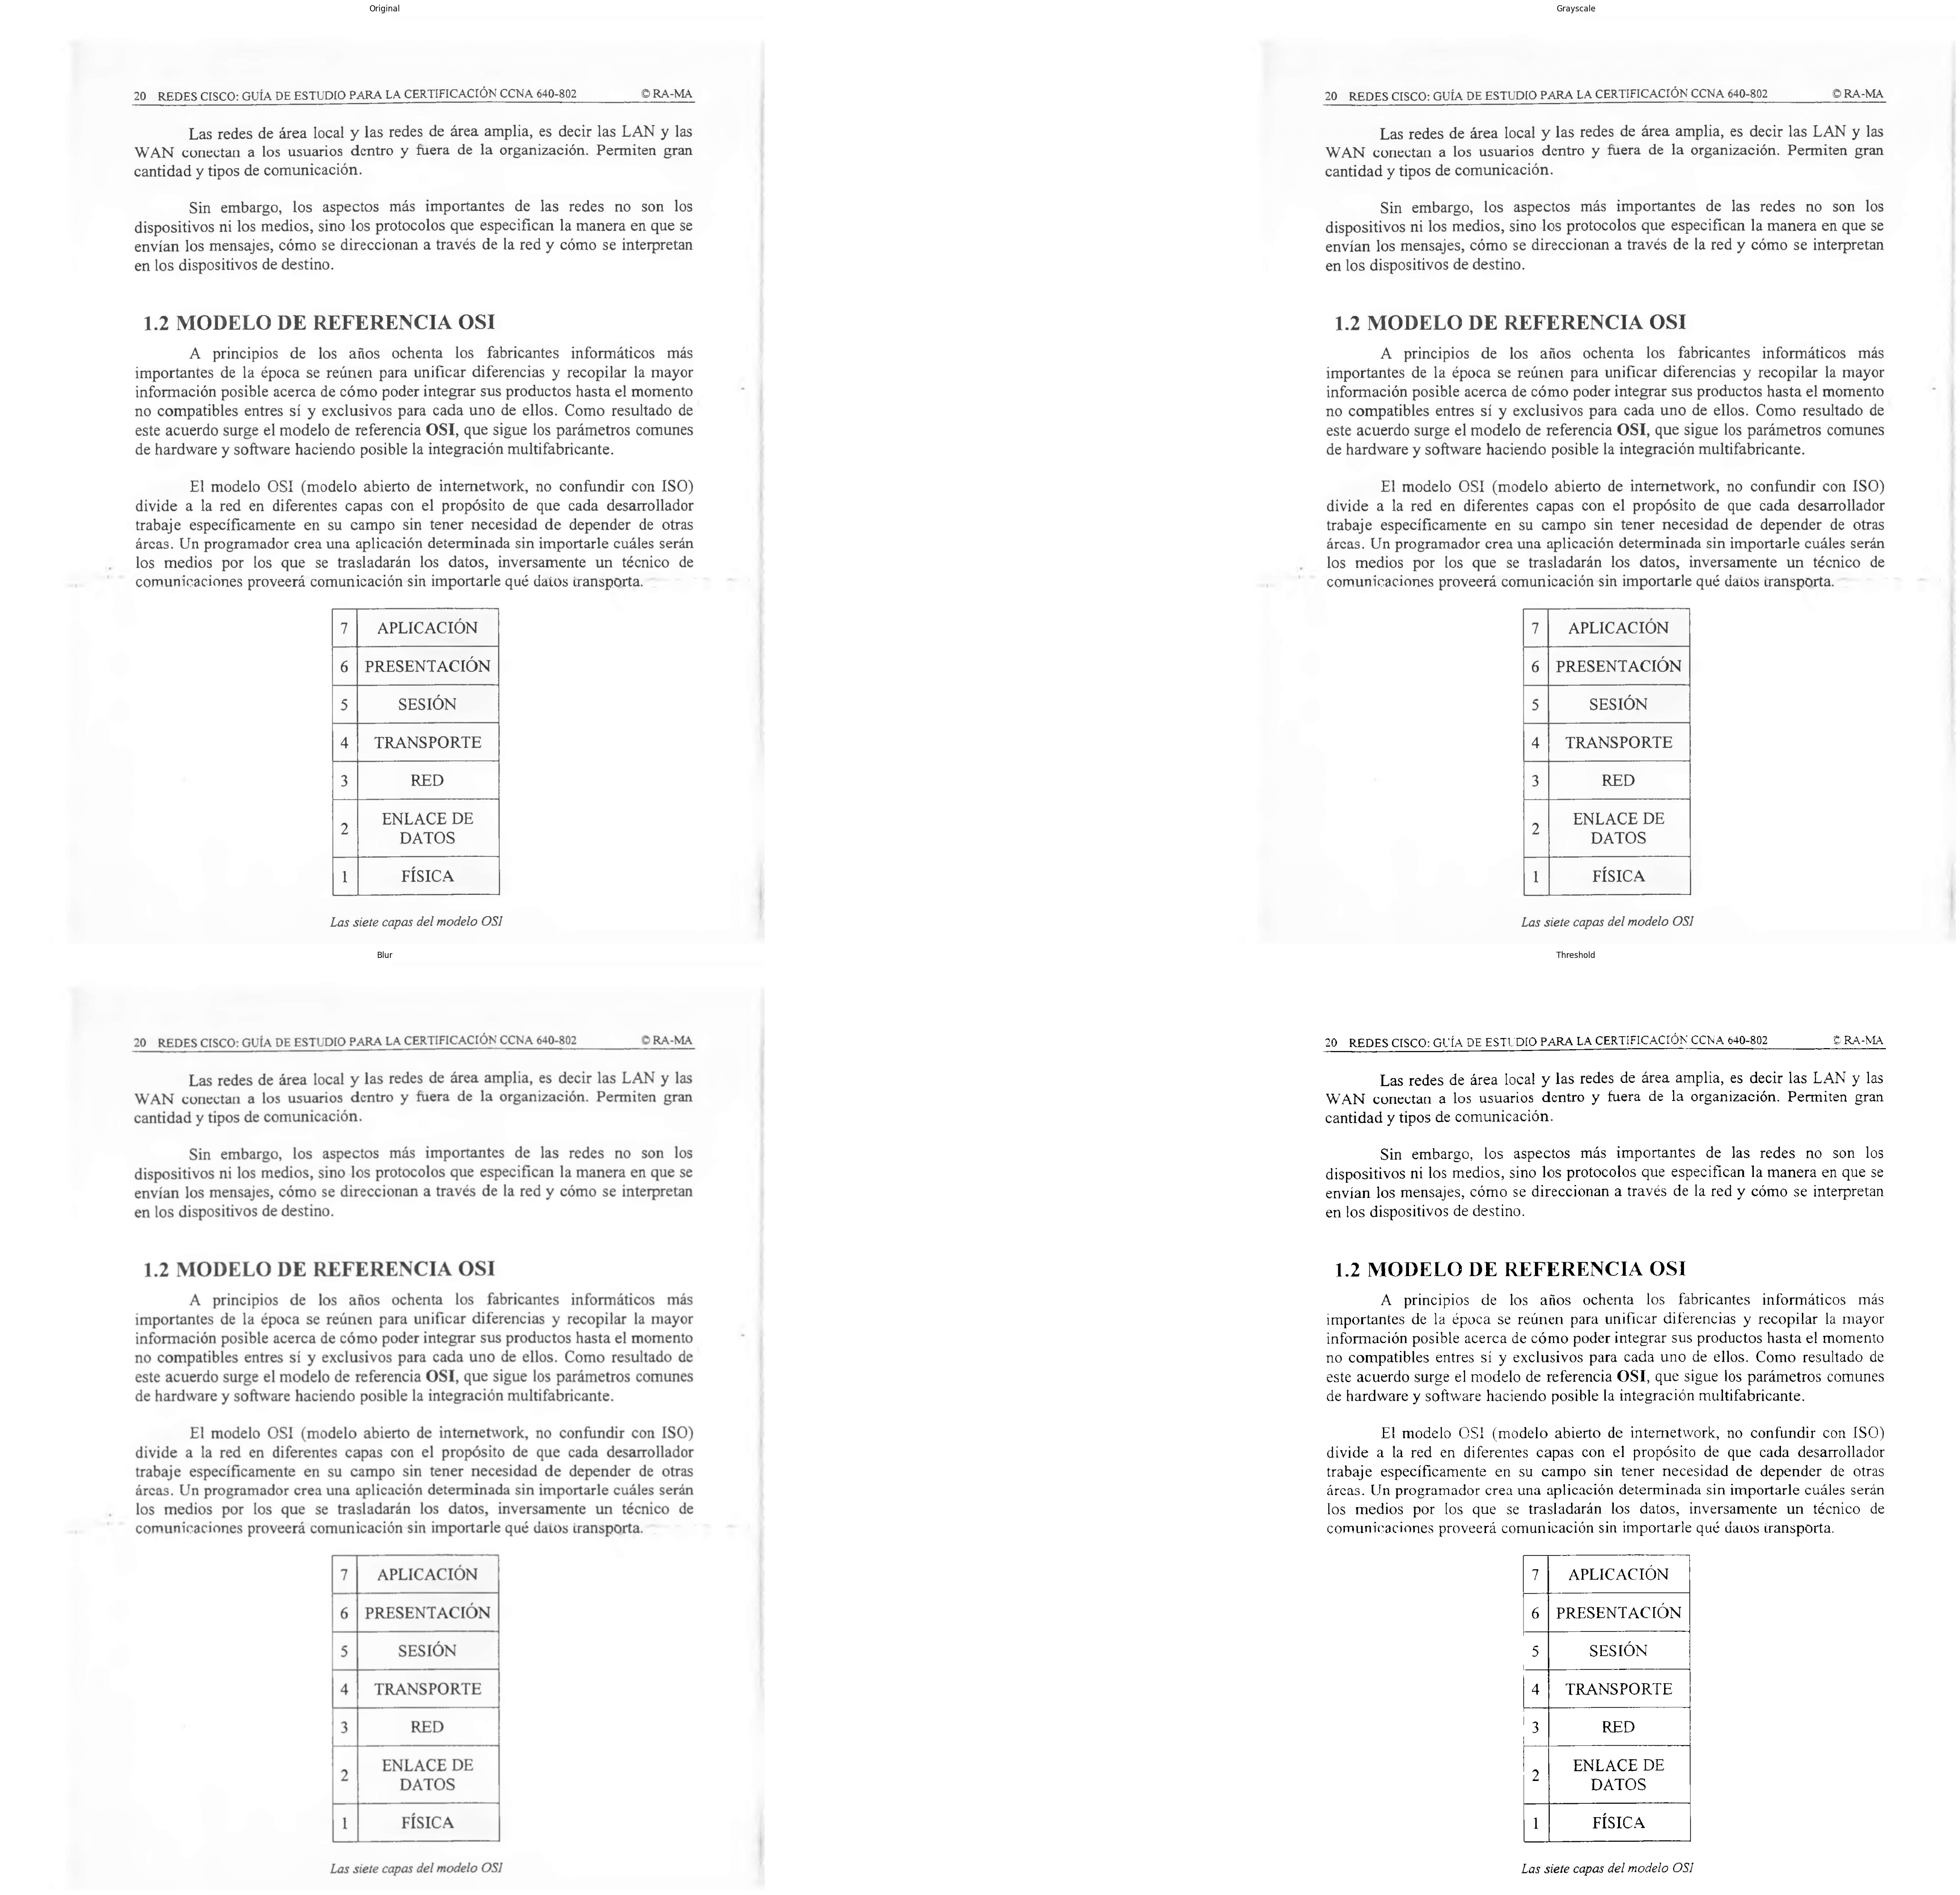

Texto extraído:

20 REDES CISCO: GUÍA DE ESTUDIO PARA LA CERTIFICACIÓN CCNA 640-802 E RA-MA

Las redes de área local y las redes de área amplia, es decir las LAN y las
WAN conectan a los usuarios dentro y fuera de la organización. Permiten gran
cantidad y tipos de comunicación.

Sin embargo, los aspectos más importantes de las redes no son los
dispositivos ni los medios, sino los protocolos que especifican la manera en que se
envian los mensajes, cómo se direccionan a través de la red y cómo se interpretan
en los dispositivos de destino.

1.2 MODELO DE REFERENCIA OSI

A principios de los años ochenta los fabricantes informáticos más
importantes de la época se reúnen para unificar diferencias y recopilar la mayor
información posible acerca de cómo poder integrar sus productos hasta el momento
no compatibles entres si y exclusivos para cada uno de ellos. Como resultado de
este acuerdo surge el modelo de referencia OSI, que sigue los parámetros comunes
de hardware y software haciendo posi

In [45]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

pytesseract.pytesseract.tesseract_cmd = r"C:\Users\<USERNAME>\AppData\Local\Programs\Tesseract-OCR\tesseract.exe"
# Titulos sobre las imagenes que se muestran con plt
pathImagen = "Lectura_Prueba.jpg"
titles = ["Original", "Grayscale", "Blur", "Threshold"]
images = [img, gray, blur, thresh]
plt.figure(figsize=(60,40))


# Procesado de la imagen
def preprocess_image_debug(path):
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # no se usa
    blur = cv2.GaussianBlur(img, (5, 5), 0) # no se usa
    ## Aca despues de varias pruebas es mejor pasar la transformacion img a binario, esto nos da muy buenos resultados
    thresh = cv2.threshold(img, 100, 255, cv2.THRESH_BINARY)[1]

    return img, gray, blur, thresh

# Extraccion del texto
def extract_text(path):
    img, gray, blur, thresh = preprocess_image_debug(path)
    text = pytesseract.image_to_string(thresh, lang="spa")
    return text

# For para mostrar la imagen procesada
img, gray, blur, thresh = preprocess_image_debug(pathImagen)
for i in range(4):
    plt.subplot(2,2,i+1)
    if i == 0:
        plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(images[i], cmap="gray")

    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()


text = extract_text(pathImagen)

print("Texto extraído:\n")
print(text)

#### Funcion final
Ahora que ya sabemos que para esta imagen en especifico su configuracion es simplementa cargar la imagen pasarlo a colores blancos/negro puros, esto nos da el siguiente resultado.



Texto extraído:

20 REDES CISCO: GUÍA DE ESTUDIO PARA LA CERTIFICACIÓN CCNA 640-802 E RA-MA

Las redes de área local y las redes de área amplia, es decir las LAN y las
WAN conectan a los usuarios dentro y fuera de la organización. Permiten gran
cantidad y tipos de comunicación.

Sin embargo, los aspectos más importantes de las redes no son los
dispositivos ni los medios, sino los protocolos que especifican la manera en que se
envian los mensajes, cómo se direccionan a través de la red y cómo se interpretan
en los dispositivos de destino.

1.2 MODELO DE REFERENCIA OSI

A principios de los años ochenta los fabricantes informáticos más
importantes de la época se reúnen para unificar diferencias y recopilar la mayor
información posible acerca de cómo poder integrar sus productos hasta el momento
no compatibles entres si y exclusivos para cada uno de ellos. Como resultado de
este acuerdo surge el modelo de referencia OSI, que sigue los parámetros comunes
de hardware y software haciendo posi

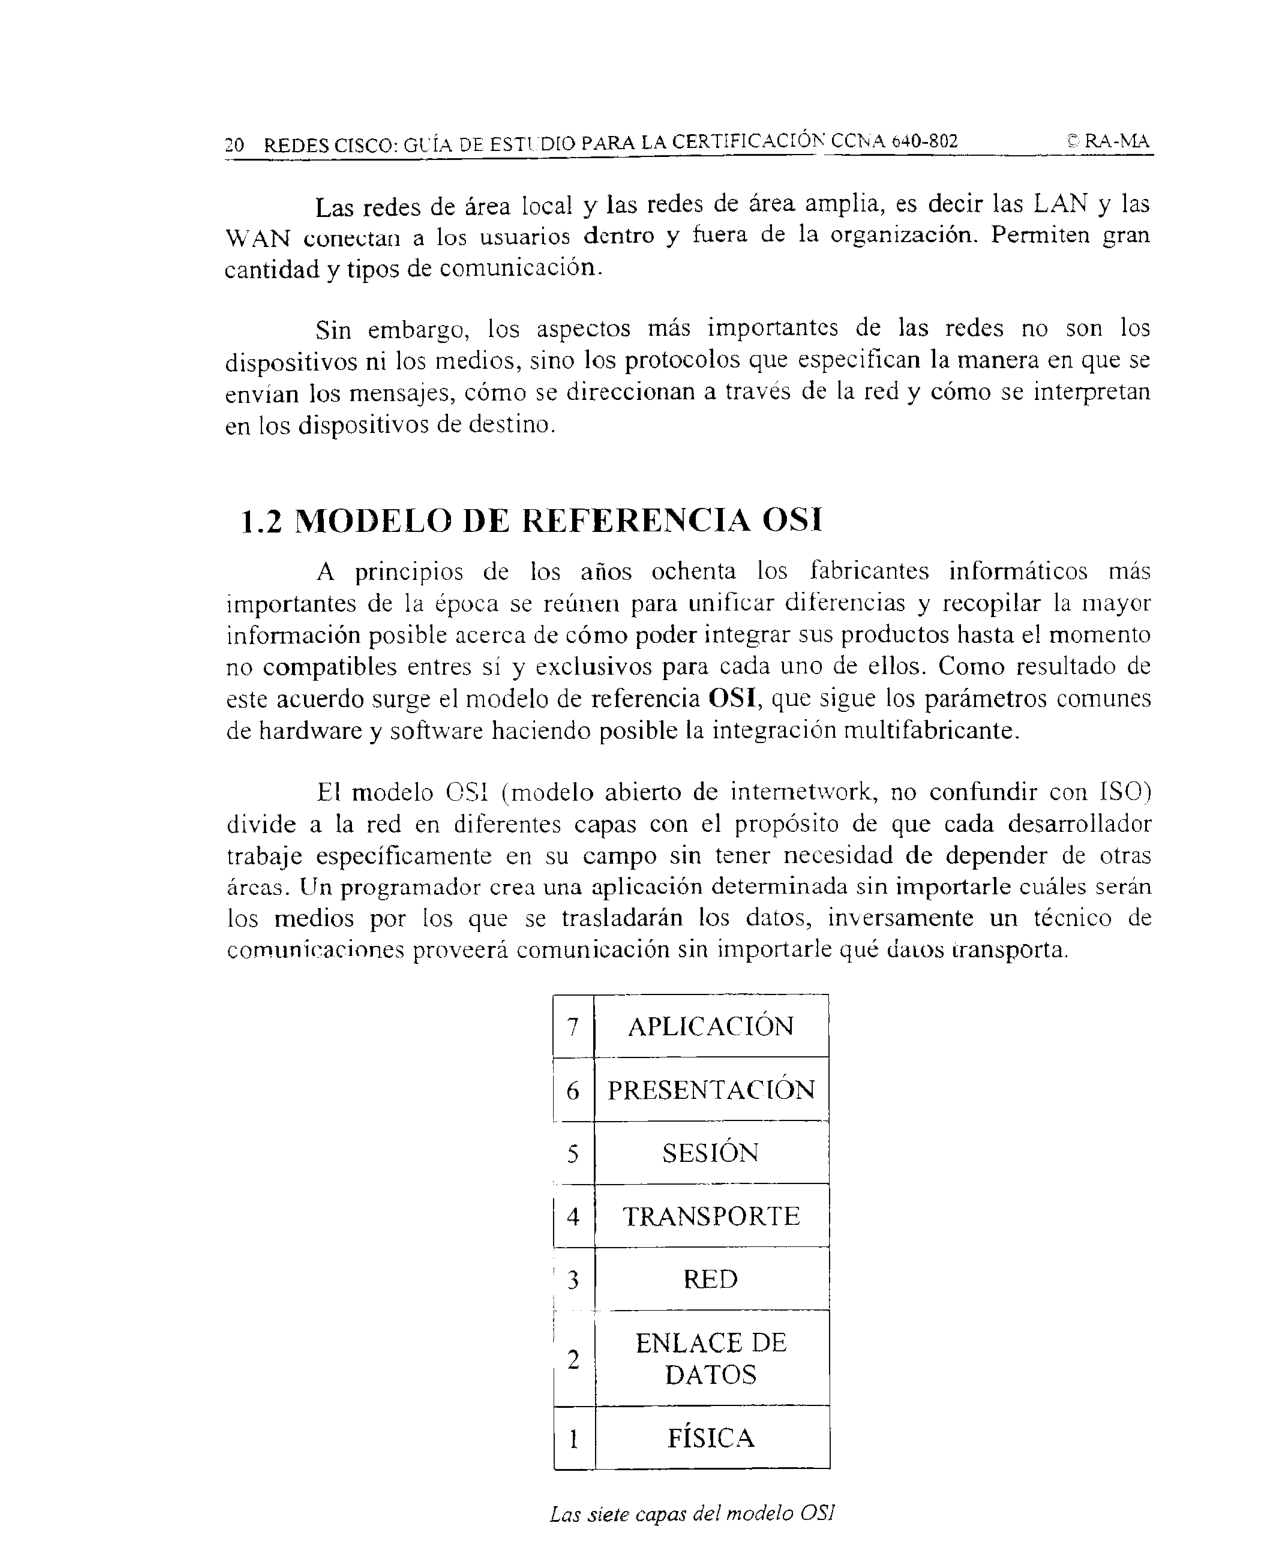

In [51]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

pytesseract.pytesseract.tesseract_cmd = r"C:\Users\<USERNAME>\AppData\Local\Programs\Tesseract-OCR\tesseract.exe"
plt.figure(figsize=(40,20))
pathImagen = "Lectura_Prueba.jpg"

def preprocess_image(path):
    img = cv2.imread(path)
    thresh = cv2.threshold(img, 100, 255, cv2.THRESH_BINARY)[1]

    return thresh

def extract_text(path):
    img = preprocess_image(path)
    text = pytesseract.image_to_string(img, lang="spa")
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    return text

text = extract_text(pathImagen)

print("Texto extraído:\n")
print(text)